## ML workflow (demo) for a supervised learning landcover classified

- Using the ODC framework
- - this example is for a single class  - agricultural areas.
  - extract ODC data for each labelled area
  - train a decision tree and parameter adjustment
  - predict landcover using trained model on new data
  - evaluate model performance with quant metrics and qual tools

This notebook is mostly based on the ML how to guide, but may expand to use the scalable ML on ODC realworld example notebook

In [1]:
%matplotlib inline

import os
import subprocess as sp
import sys
from io import StringIO
import random

import datacube
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pydotplus
import rasterio
import shapely
import xarray as xr

from pprint import pprint
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D
from datacube.utils import geometry
from datacube.utils.cog import write_cog
from datacube.utils.geometry import assign_crs
from IPython.display import Image
from odc.io.cgroups import get_cpu_quota
from sklearn import model_selection, tree
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

sys.path.insert(1, ".../Tools/")
import warnings

from dea_tools.bandindices import calculate_indices
from dea_tools.classification import collect_training_data, predict_xr

warnings.filterwarnings("ignore")

In [2]:
path = "../Real_world_examples/Scalable_machine_learning/data/crop_training_WA.geojson"
field = "class"

ncpus = round(get_cpu_quota())

In [3]:
input_data = gpd.read_file(path)

# input_data.head()
input_data.explore(column=field)

## extract training data

`collect_training_data` will take the geojson class labels and extract training data from the datacube over the locations specified by the geojson geometries.

It also pre-processes the training data a bit by stacking the arrays into a "useful format"(?) and removing and `inf` or `NaN` values.

You can set `zonal_stats` within the `collect_training_data` function. Dfault is none (all values returned) or you can specify `mean`, `median`, `max`, `min`.

Same as above, set up a datacube query to use for getting the data over the target areas.


In [4]:
zonal_stats = None

time = ('2014')
resolution = (-30, 30)
output_crs ='epsg:3577'

In [5]:
# inputs for the feature_layers function
query = {"time": time, 
         "resolution": resolution, 
         "output_crs": output_crs}

In [6]:
def feature_layers(query):
    
    # Connect to the datacube
    dc = datacube.Datacube(app='custom_feature_layers')
    
    # Load ls8 geomedian
    ds = dc.load(product='ga_ls8cls9c_gm_cyear_3',
                 **query)
    
    # Calculate some band indices
    da = calculate_indices(ds,
                           index=['NDVI', 'LAI', 'MNDWI'],
                           drop=False,
                           collection='ga_ls_3')
    
    # Add Fractional cover percentiles
    fc = dc.load(product='ga_ls_fc_pc_cyear_3',
                 measurements=['pv_pc_10', 'pv_pc_50', 'pv_pc_90'], # only the PV band
                 like=ds.geobox, # will match geomedian extent
                 time=query.get('time'),  # use time if in query
                 dask_chunks=query.get('dask_chunks')  # use dask if in query
                )

    # Merge results into single dataset 
    result = xr.merge([da, fc], compat='override')
    
    return result

In [7]:
%%time
column_names, model_input = collect_training_data(
    gdf=input_data,
    dc_query=query,
    ncpus=ncpus,
    return_coords=False,
    field=field,
    zonal_stats=zonal_stats,
    feature_func=feature_layers)

  0%|          | 0/430 [00:00<?, ?it/s]

Percentage of possible fails after run 1 = 0.0 %
Removed 0 rows wth NaNs &/or Infs
Output shape:  (430, 17)
CPU times: user 993 ms, sys: 188 ms, total: 1.18 s
Wall time: 12min 19s


In [8]:
print(column_names)
print('')
print(np.array_str(model_input, precision=2, suppress_small=True))

['class', 'nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2', 'sdev', 'edev', 'bcdev', 'count', 'NDVI', 'LAI', 'MNDWI', 'pv_pc_10', 'pv_pc_50', 'pv_pc_90']

[[   1.  953. 1416. ...   10.   16.   78.]
 [   1. 1172. 1777. ...    2.    7.   95.]
 [   1. 1129. 1605. ...    3.    6.   68.]
 ...
 [   0.  581. 1044. ...    2.    5.    9.]
 [   0.  655. 1024. ...   11.   20.   29.]
 [   0.  459.  661. ...   34.   42.   54.]]


In [10]:
output_file='results/test_training_data.txt'

np.savetxt(output_file, model_input, header=' '.join(column_names), fmt='%4f')

## 2: inspect training data

In [11]:
training_data = 'results/test_training_data.txt'

class_dict = {'crop':1, 'noncrop':0}

field='class'

In [12]:
# load data

model_input=np.loadtxt(training_data)

# loac column_names
with open(training_data, 'r') as file:
    header=file.readline()

column_names=header.split()[1:]

model_col_indices=[column_names.index(var_name) for var_name in column_names[1:]]

### data wrangling

In [36]:
# extract each class from the training data into a dictionary so we can plot the data clearly

dfs = {}

#put data in a dataframe, split into features and labels
model_input_df = pd.DataFrame(model_input, columns=column_names)
X = model_input_df.drop(field, axis=1) #everything except the field column
y = model_input_df[[field]] #only the field column

# fit the scaler to all features
scaler = StandardScaler(with_mean=False)
scaler.fit(X)

for key, value in class_dict.items():
    print(key, value)
    # select rows in model_input that match the class identifier (value)
    arr = model_input[model_input[:, 0]==value]
    # make a DF for that class, rename the columns, drop 'field'
    df = pd.DataFrame(arr).rename(columns={i:column_names[i] for i in range(0, len(column_names))}).drop(field, axis=1)
    # scale the class DF
    scaled_df = scaler.transform(df)
    scaled_df = pd.DataFrame(scaled_df, columns=df.columns)
    # add the scaled dataframe to dfs
    dfs.update({key:scaled_df})

crop 1
noncrop 0


Text(0.5, 1.0, 'Training Data Knowledge-Base')

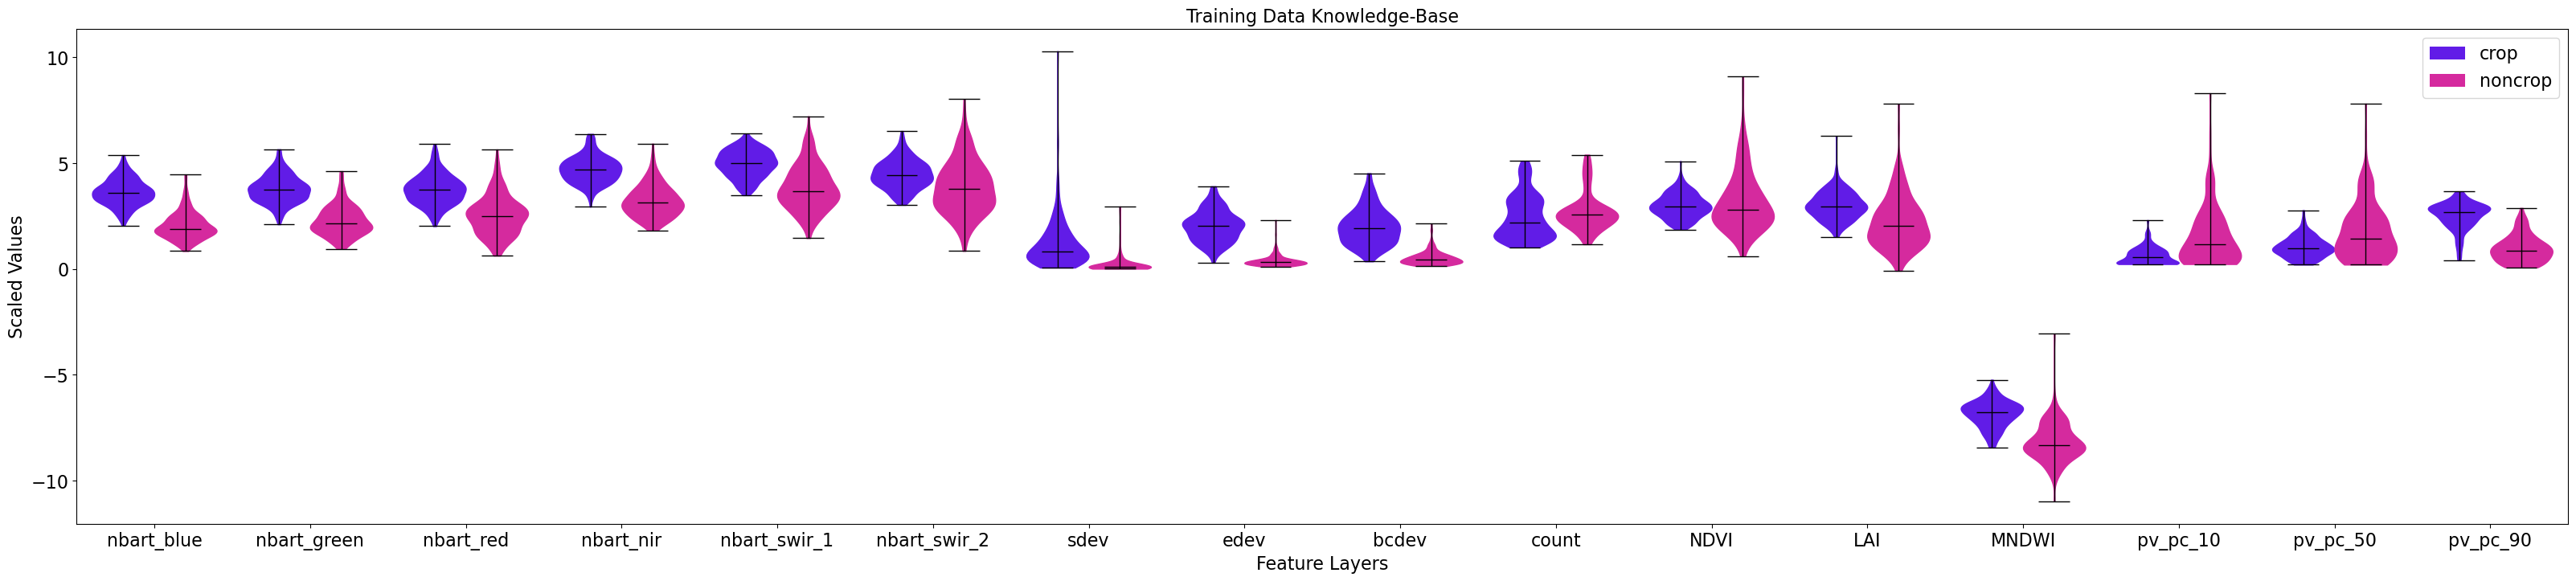

In [37]:
# Violin plot to see data

#make rando list of colors same length as num of classes
get_colors = lambda n:list(
    map(lambda i: '#' + '%06x' % random.randint(0, 0xFFFFFF), range(n))
)

colors = get_colors(len(dfs))

# make list of offsets and widths for plot
start = -0.2 #if this is a positive num, the violins overlap
end = 0.2
offsets = list(np.linspace(start, end, len(dfs)))

if len(dfs) == 2:
    width=0.4
else:
    width=np.abs(offsets[0] - offsets[1])

# create fig and axes

fig, ax = plt.subplots(figsize=(40,8))

for key, color, offset in zip(dfs, colors, offsets):
    pp = ax.violinplot(dfs[key].values,
                      showmedians=True,
                      positions=np.arange(dfs[key].values.shape[1]) + offset,
                      widths=width)
    # colors of the plots
    for pc in pp['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(1)
    # linestyles
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        vp = pp[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(1)

# tidy up and add title/legend
ax.legend([Patch(facecolor=c) for c in colors], 
          [key for key in dfs], loc='upper right', 
          fontsize=16)
ax.set_xticks(np.arange(len(column_names[1:])))
ax.set_xticklabels(column_names[1:])
ax.set_xlim(-0.5, len(column_names[1:]) - .5)
ax.set_ylabel("Scaled Values", fontsize=16)
ax.set_xlabel("Feature Layers", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_title("Training Data Knowledge-Base", fontsize=16)

**We're looking for features that show good separation between the crop and non-crop classes.**

In the above graph that looks like blue, green, nir, sdev, edev, and PV_PV_90.

Having features with good separation lets us know our model will probably have the right features to distinguish between the classes alter on.

### Feature importance

We extract estimates of how important each feature will be for training the classifier. This is helpful for optimising feature space, as we can just choose the most important ones (but we're not doing that yet).

In [38]:
model=RandomForestClassifier(random_state=42)
model.fit(X,y.values.ravel())

RandomForestClassifier(random_state=42)

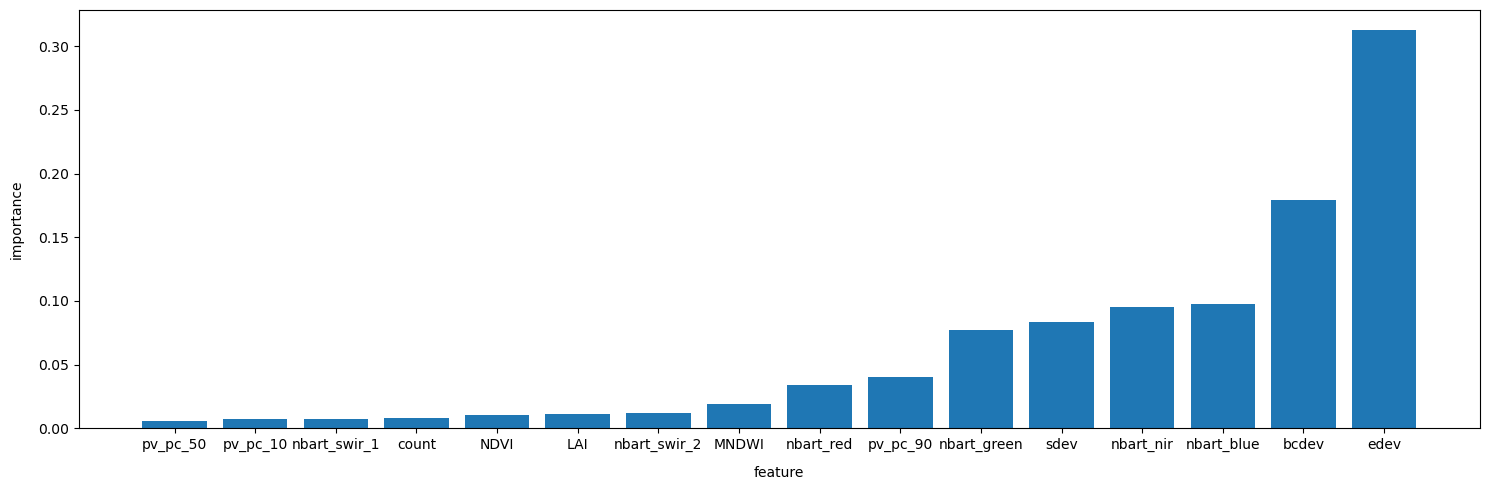

In [39]:
order=np.argsort(model.feature_importances_)

plt.figure(figsize=(15,5))
plt.bar(x=np.array(column_names[1:])[order],
       height=model.feature_importances_[order]) #Need to understand this better
plt.gca().set_ylabel('importance', labelpad=10)
plt.gca().set_xlabel('feature', labelpad=10)
plt.tight_layout()

So based on this graph, edev, bcdev, blue and sdev are the most important features for our purpose.

**Feature separability vs feature importance:**

- the violin plots showed a class's distribution w/ respect to a RS variable or stat, and this is probably related to biophysical properties for the class.
- The importance estimate is related to how much a feature reduced entropy of a dataset during the creation of the decision tree, which is not always correlated with separation.

**TLDR: Be careful drawing inferences about the biophysical properties of a class based on feature importance.**

### PCA

yay...

We're going to calculate and plot the first two components for the dataset. IT will help visualise the dataset because visualising 16 variables is... impossible.



In [40]:
X_scaled = scaler.transform(X)

In [42]:
# two components
pca2 = PCA(n_components=2)
pca2_fit = pca2.fit_transform(X_scaled)

#three components
pca3 = PCA(n_components=3)
pca3_fit=pca3.fit_transform(X_scaled)

# add back to the df
pca2_df = pd.DataFrame(data=pca2_fit, columns=['PC1', 'PC2'])
pca3_df = pd.DataFrame(data=pca3_fit, columns=['PC1', 'PC2', 'PC3'])

# concat with classes
result2 = pd.concat([pca2_df, pd.DataFrame({'class': model_input[:, 0]})], axis=1)
result3 = pd.concat([pca3_df, pd.DataFrame({'class': model_input[:, 0]})], axis=1)

In [43]:
# print the variance explained by the 2 and 3 component PCA's
a2, b2 = pca2.explained_variance_ratio_
a3, b3, c3 = pca3.explained_variance_ratio_

print("Variance explained by two principal components = " +
      str(round((a2 + b2) * 100, 2)) + " %")
print("Variance explained by three principal components = " +
      str(round((a3 + b3 + c3) * 100, 2)) + " %")

Variance explained by two principal components = 72.78 %
Variance explained by three principal components = 82.07 %


Text(0.5, 0, 'PC3')

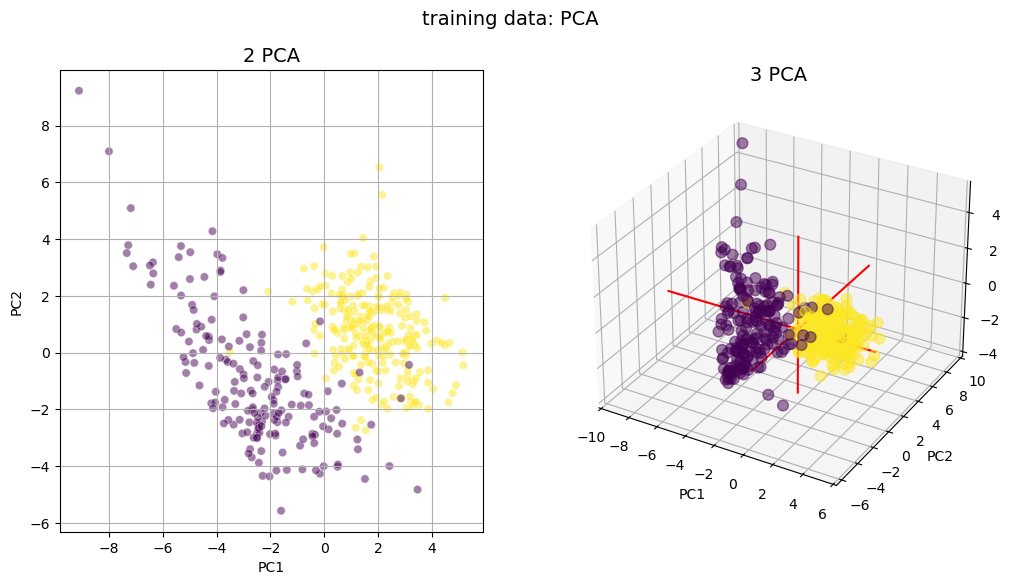

In [45]:
fig = plt.figure(figsize=(12,6))
fig.suptitle('training data: PCA', fontsize=14)

ax = fig.add_subplot(1,2,1)

scatter1 = sns.scatterplot(
    x='PC1',
    y='PC2',
    data=result2,
    hue='class',
    hue_norm=tuple(np.unique(result2['class'])),
    palette='viridis',
    legend=False,
    alpha=0.5,
    ax=ax
)

ax.set_title('2 PCA', fontsize=14)
ax.grid(True)

# 3 component plot
ax=fig.add_subplot(1,2,2, projection='3d')
scatter2=ax.scatter(result3['PC1'],
                   result3['PC2'],
                   result3['PC3'],
                   c=result3['class'],
                   s=60,
                   alpha=0.5)

# make simple, vare axis lines through space (?)
xAxisLine= ((min(result3['PC1']), max(result3['PC1'])), (0,0), (0,0))
ax.plot(xAxisLine[0], xAxisLine[1], xAxisLine[2], 'r')

xAxisLine= ((0,0), (min(result3['PC2']), max(result3['PC2'])), (0,0))
ax.plot(xAxisLine[0], xAxisLine[1], xAxisLine[2], 'r')

xAxisLine= ((0,0), (0,0),(min(result3['PC3']), max(result3['PC3'])))
ax.plot(xAxisLine[0], xAxisLine[1], xAxisLine[2], 'r')

ax.set_title('3 PCA', fontsize=14)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')